In [1]:
import gcinfo

gcinfo.list_resources(gcinfo.search_datasets(query='title:"Asylum Claimants – Monthly IRCC Updates"')["results"][0])


=== Asylum Claimants – Monthly IRCC Updates ===
ID: b6cbcf4d-f763-4924-a2fb-8cc4a06e3de4
Org: Immigration, Refugees and Citizenship Canada | Immigration, Réfugiés et Citoyenneté Canada
Notes: Temporary residents in the humanitarian population who request refugee protection upon or after arrival in Canada. 

__This data should not be used as an indication of the number of asylum claimants...
Citation: Immigration, Refugees and Citizenship Canada. Asylum Claimants – Monthly IRCC Updates
  [XLSX    ] Canada - Asylum Claimants by Claim Office Type, Province / Territory of Claim and Claim Month
           https://www.ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-Asylum-OfficeType_Prov.xlsx
  [XLSX    ] Canada - Asylum Claimants by Claim Office Type, Province / Territory of Claim and Claim Month
           https://www.ircc.canada.ca/opendata-donneesouvertes/data/FR_ODP-Asylum-OfficeType_Prov.xlsx
  [CSV     ] [rounded numbers - not for calculations] Canada - Asylum Claimants by Claim 

In [2]:
df = gcinfo.download_xlsx("https://www.ircc.canada.ca/opendata-donneesouvertes/data/EN_ODP-Asylum-Top_25_CITZ_Office_Type_last_year.xlsx")

Using cached file: cache\EN_ODP-Asylum-Top_25_CITZ_Office_Type_last_year.xlsx


In [3]:
df

,"Canada - Asylum Claimants by Top Twenty-Five Countries of Citizenship (2025 ranking), Claim Office Type and Claim Year, January 2015 - June 2026",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 188,Unnamed: 189,Unnamed: 190,Unnamed: 191,Unnamed: 192,Unnamed: 193,Unnamed: 194,Unnamed: 195,Unnamed: 196,Unnamed: 197
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Country of Citizenship and Office Type,NaN,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,Q1,NaN,NaN,NaN,Q2,NaN,NaN,NaN,...,2025 Total,Q1,NaN,NaN,NaN,Q2,NaN,NaN,NaN,2026 Total
3,NaN,NaN,Jan,Feb,Mar,Q1 Total,Apr,May,Jun,Q2 Total,...,NaN,Jan,Feb,Mar,Q1 Total,Apr,May,Jun,Q2 Total,NaN
4,NaN,Airport,0,--,0,--,5,0,0,5,...,255,15,10,5,30,10,5,15,30,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,Total,NaN,"1,165","1,145","1,130","3,440","1,125","1,165","1,325","3,615",...,"113,105","6,455","5,915","6,160","18,530","3,835","3,615","3,385","10,835","29,370"
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Notes: \n— Please note that all values between...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_clean = df[["Canada - Asylum Claimants by Top Twenty-Five Countries of Citizenship (2025 ranking), Claim Office Type and Claim Year, January 2015 - June 2026", "Unnamed: 197"]].iloc[7:-5].dropna()
df_clean.shape
df_clean.head(30)

,"Canada - Asylum Claimants by Top Twenty-Five Countries of Citizenship (2025 ranking), Claim Office Type and Claim Year, January 2015 - June 2026",Unnamed: 197
7,(1) Haiti,"2,705"
12,(2) India,"4,360"
17,(3) Iran,"2,050"
22,(4) Nigeria,"1,610"
27,(5) Mexico,"1,485"
32,"(6) China, People's Republic of","1,375"
37,(7) Pakistan,"1,155"
41,(8) Bangladesh,850
45,(9) Ghana,630
50,(10) Colombia,730


In [5]:
df_clean["Unnamed: 197"].apply(lambda x: int(x.replace(",", ""))).sum()

np.int64(29360)

In [6]:
df.iloc[[121]]["Unnamed: 197"] # Total

121    29,370
Name: Unnamed: 197, dtype: object

In [7]:
df_clean["Canada - Asylum Claimants by Top Twenty-Five Countries of Citizenship (2025 ranking), Claim Office Type and Claim Year, January 2015 - June 2026"].unique().tolist()

['(1) Haiti',
 '(2) India',
 '(3) Iran',
 '(4) Nigeria',
 '(5) Mexico',
 "(6) China, People's Republic of",
 '(7) Pakistan',
 '(8) Bangladesh',
 '(9) Ghana',
 '(10) Colombia',
 '(11) Sri Lanka',
 '(12) Algeria',
 '(13) United States of America',
 '(14) Guinea, Republic of',
 '(15) Romania',
 '(16) Nepal',
 '(17) Congo, Democratic Republic of the',
 '(18) Venezuela',
 '(19) Cameroon, Federal Republic of',
 '(20) Turkey',
 '(21) Ivory Coast, Republic of',
 '(22) Senegal',
 '(23) Ethiopia',
 '(24) Chile',
 '(25) Ukraine',
 'Other Countries']

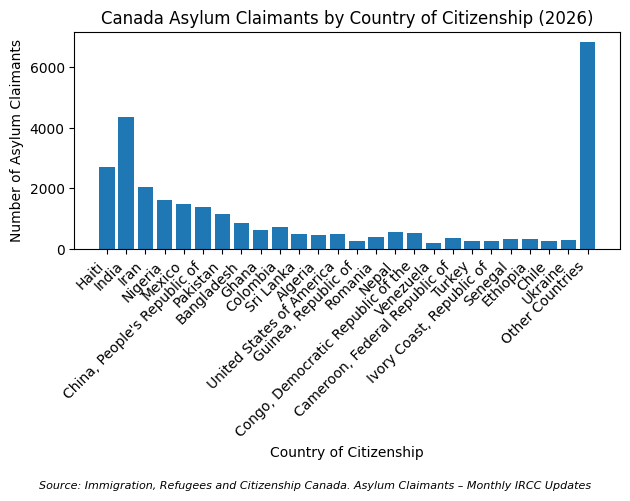

In [8]:
import matplotlib.pyplot as plt

# Clean df_clean
df = df_clean.copy()
df.columns = ["Country", "Claimants"]

# Remove the ranking prefix like "(1) "
df["Country"] = df["Country"].str.replace(r"^\(\d+\)\s*", "", regex=True)

# Convert claimants to numbers
df["Claimants"] = df["Claimants"].str.replace(",", "").astype(int)

fig, ax = plt.subplots()
ax.bar(df["Country"], df["Claimants"])
ax.set_title("Canada Asylum Claimants by Country of Citizenship (2026)")
ax.set_xlabel("Country of Citizenship")
ax.set_ylabel("Number of Asylum Claimants")
plt.xticks(rotation=45, ha="right")
plt.subplots_adjust(bottom=0.3)
plt.figtext(
    0.5, -0.03,
    "Source: Immigration, Refugees and Citizenship Canada. Asylum Claimants – Monthly IRCC Updates",
    ha="center",
    fontsize=8,
    style="italic"
)
plt.tight_layout()
plt.show()